In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

MY_KEY = os.getenv("MY_KEY")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import google.generativeai as genai
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

data = {
    'City': ['Mumbai', 'Delhi', 'Bengaluru', 'Chennai', 'Hyderabad', 'Pune',
             'Kolkata', 'Ahmedabad', 'Jaipur', 'Chandigarh'],
    'Customers': [120, 90, 150, 80, 130, 70, 110, 95, 60, 100],
    'Sales': [15000, 11800, 18000, 9500, 16000, 8900, 13800, 12000, 7800, 12800]
}

df = pd.DataFrame(data)
df.head(12)

,City,Customers,Sales
0,Mumbai,120,15000
1,Delhi,90,11800
2,Bengaluru,150,18000
3,Chennai,80,9500
4,Hyderabad,130,16000
5,Pune,70,8900
6,Kolkata,110,13800
7,Ahmedabad,95,12000
8,Jaipur,60,7800
9,Chandigarh,100,12800


In [ ]:
genai.configure(api_key=MY_KEY)
model = genai.GenerativeModel('gemini-2.5-flash')

In [ ]:
def ask(query):
    prompt = f"""
    DataFrame: {df.to_string()}

    Query: {query}

    Generate Python code. Available: df, pd, plt, np, LinearRegression, train_test_split, r2_score, mean_squared_error
    IMPORTANT:
    - Always print() text results
    - For plots use plt.show() NOT plt.print()
    - When predicting with LinearRegression, use proper format: model.predict([[value]]) or model.predict(pd.DataFrame([[value]], columns=['column_name']))
    Code only, no explanation.
    """

    code = model.generate_content(prompt).text
    code = code.replace('```python', '').replace('```', '').strip()

    # Fix common mistakes
    code = code.replace('plt.print()', 'plt.show()')

    print(f"\n--- Query: {query} ---")
    try:
        import warnings
        warnings.filterwarnings('ignore')
        exec(code, {
            'df': df,
            'pd': pd,
            'plt': plt,
            'np': np,
            'LinearRegression': LinearRegression,
            'train_test_split': train_test_split,
            'r2_score': r2_score,
            'mean_squared_error': mean_squared_error
        })
    except Exception as e:
        print(f"Error: {e}")
        print(f"Generated code:\n{code}")

## Basic calculations

In [ ]:
ask("Which city has highest sales?")


--- Query: Which city has highest sales? ---
Bengaluru


In [ ]:
ask("Show me average sales per city")


--- Query: Show me average sales per city ---
City
Ahmedabad     12000.0
Bengaluru     18000.0
Chandigarh    12800.0
Chennai        9500.0
Delhi         11800.0
Hyderabad     16000.0
Jaipur         7800.0
Kolkata       13800.0
Mumbai        15000.0
Pune           8900.0
Name: Sales, dtype: float64


## visualization through plots


--- Query: create a barplot for sales and city ---


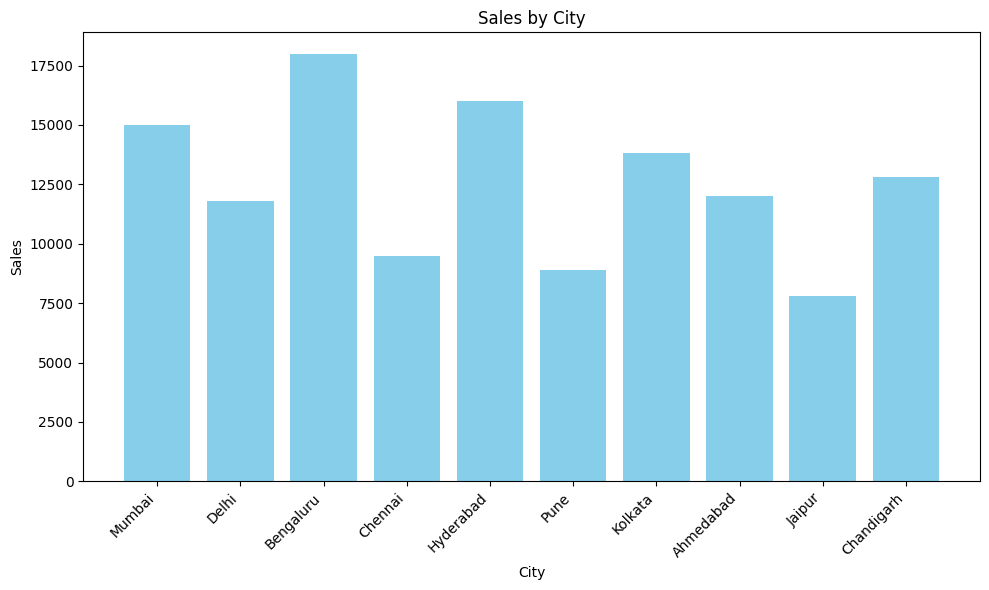

In [ ]:
ask("create a barplot for sales and city")


--- Query: Create a pie chart of sales distribution ---


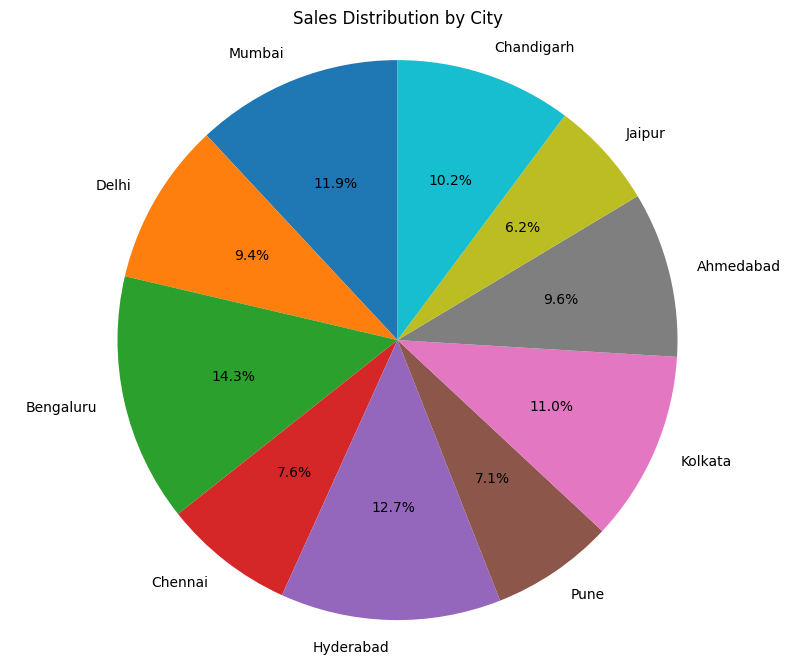

In [ ]:
ask("Create a pie chart of sales distribution")

# Build a simple regression model for the given data



--- Query: Build a linear regression to predict Sales from number of customers with R2 score and plot ---
Linear Regression Model Performance:
Coefficient (Customers): 118.07
Intercept: 631.72
R2 Score: 0.96
Mean Squared Error: 150633.06


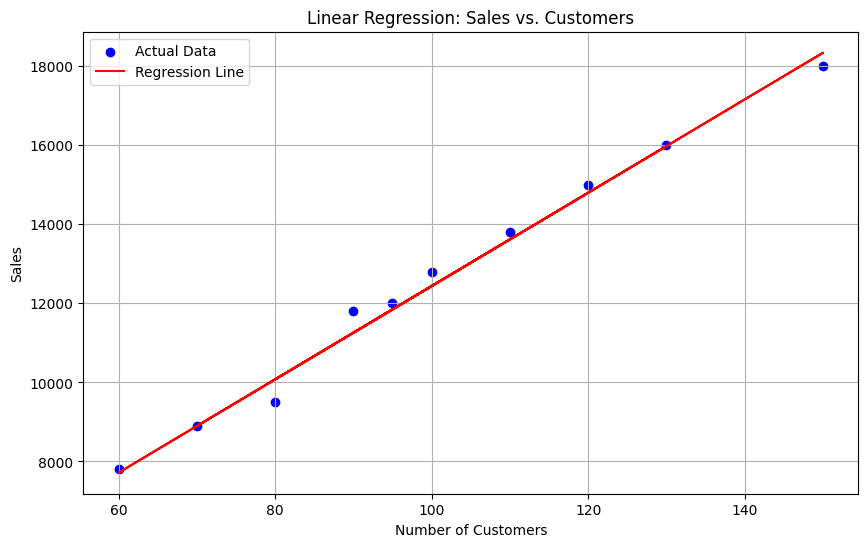

In [ ]:
ask("Build a linear regression to predict Sales from number of customers with R2 score and plot")

# Prediction

In [ ]:
ask("If we have 180 customers , what will be our sales in rs?")


--- Query: If we have 180 customers , what will be our sales in rs? ---
If we have 180 customers, our sales will be Rs. 21841.60
